In [8]:
# Cell 0: Session Restore + Full Preprocessing Pipeline
# Run this cell first every session.
# Loads raw modeling data and applies all preprocessing decisions
# producing clean X_clean ready for MICE.

import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Move to project root if running from notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Paths
data_proc = 'data/processed/'
data_raw  = 'data/raw/'
fig_dir   = 'outputs/figures/'
src_dir   = 'src/'

# Load base modeling dataset
X = pd.read_csv(os.path.join(data_proc, 'x_modeling.csv'), low_memory=False)
y = pd.read_csv(os.path.join(data_proc, 'y_msss.csv')).squeeze()

print(f"Base dataset loaded: {X.shape[0]:,} rows x {X.shape[1]:,} columns")

X_clean = X.copy()

# Step 1: Alcohol structural zero fill
# Non-drinkers were never asked follow-up questions — true value is 0
non_drinker_mask      = (X_clean['ALQ111'] == 2) | (X_clean['ALQ121'] == 0)
alcohol_followup_cols = [c for c in [
    'ALQ130', 'ALQ142', 'ALQ170',
    'ALQ270', 'ALQ280', 'ALQ290'
] if c in X_clean.columns]
X_clean.loc[non_drinker_mask, alcohol_followup_cols] = \
    X_clean.loc[non_drinker_mask, alcohol_followup_cols].fillna(0)
print(f"Step 1  : alcohol zero-fill ({non_drinker_mask.sum()} non-drinkers)")

# Step 2: Physical activity structural zero fill + MET engineering
# Inactive participants get 0 minutes — not missing
pad_fill_map = {
    'PAD615': ('PAQ605', 2),
    'PAD630': ('PAQ620', 2),
    'PAD645': ('PAQ635', 2),
    'PAD660': ('PAQ650', 2),
    'PAD675': ('PAQ665', 2),
}
for pad_col, (paq_col, no_code) in pad_fill_map.items():
    if pad_col in X_clean.columns and paq_col in X_clean.columns:
        mask = X_clean[paq_col] == no_code
        X_clean.loc[mask, pad_col] = X_clean.loc[mask, pad_col].fillna(0)

met_components = {
    'vigorous_work': ('PAQ610', 'PAD615', 8),
    'moderate_work': ('PAQ625', 'PAD630', 4),
    'walking'      : ('PAQ640', 'PAD645', 4),
    'vigorous_rec' : ('PAQ655', 'PAD660', 8),
    'moderate_rec' : ('PAQ670', 'PAD675', 4),
}
X_clean['total_MET_minutes'] = 0.0
for _, (days_col, min_col, met) in met_components.items():
    if days_col in X_clean.columns and min_col in X_clean.columns:
        X_clean['total_MET_minutes'] += (
            X_clean[days_col].fillna(0) *
            X_clean[min_col].fillna(0) * met
        )
X_clean['total_MET_minutes'] = np.log1p(X_clean['total_MET_minutes'])

paq_pad_to_drop = [c for c in [
    'PAQ605', 'PAQ610', 'PAQ620', 'PAQ625', 'PAQ635',
    'PAQ640', 'PAQ650', 'PAQ655', 'PAQ665', 'PAQ670',
    'PAD615', 'PAD630', 'PAD645', 'PAD660', 'PAD675'
] if c in X_clean.columns]
X_clean = X_clean.drop(columns=paq_pad_to_drop)
print(f"Step 2  : MET minutes engineered, {len(paq_pad_to_drop)} PAQ/PAD columns dropped")

# Step 3: Drop columns with >40% or 100% missingness
missing_pct       = (X_clean.isnull().sum() / len(X_clean) * 100)
cols_all_missing  = missing_pct[missing_pct == 100].index.tolist()
cols_high_missing = missing_pct[(missing_pct > 40) &
                                (missing_pct < 100)].index.tolist()
X_clean = X_clean.drop(columns=cols_all_missing + cols_high_missing,
                        errors='ignore')
print(f"Step 3  : dropped {len(cols_all_missing)} all-missing, "
      f"{len(cols_high_missing)} >40% missing")

# Step 4: Drop near-zero variance columns (>95% same value)
nzv_cols = [
    col for col in X_clean.select_dtypes(include=[np.number]).columns
    if X_clean[col].value_counts(normalize=True).iloc[0] >= 0.95
]
X_clean = X_clean.drop(columns=nzv_cols, errors='ignore')
print(f"Step 4  : dropped {len(nzv_cols)} near-zero variance columns")

# Step 5: Drop object/string columns
# SLQ300/310/320/330 are clock times redundant with SLD012/SLD013
# BPAOARM is measurement protocol, not a clinical predictor
obj_cols = X_clean.select_dtypes(include=['object']).columns.tolist()
X_clean  = X_clean.drop(columns=obj_cols, errors='ignore')
print(f"Step 5  : dropped {len(obj_cols)} object columns")

# Step 6: Drop survey weights and design variables
# These are analytical weights, not predictors
weight_cols = [c for c in [
    'WTDR2DPP', 'WTDR2DPP_DR2TOT', 'WTDRD1PP', 'WTDRD1PP_DR2TOT',
    'WTINTPRP', 'WTSAFPRP', 'WTSAFPRP_GLU', 'WTMECPRP',
    'SDMVPSU',  'SDMVSTRA'
] if c in X_clean.columns]
X_clean = X_clean.drop(columns=weight_cols, errors='ignore')
print(f"Step 6  : dropped {len(weight_cols)} survey weight/design columns")

# Step 7: Drop direct glucose leakage columns
# LBXSGL and LBDSGLSI are fasting glucose in different units
# Same measurement as LBXGLU which was excluded as diagnostic component
glucose_leakage = [c for c in ['LBXSGL', 'LBDSGLSI'] if c in X_clean.columns]
X_clean = X_clean.drop(columns=glucose_leakage, errors='ignore')
print(f"Step 7  : dropped {len(glucose_leakage)} direct glucose leakage columns")

# Step 8: Drop SI duplicate biochemistry columns
# Keep conventional units (LBX*), drop SI duplicates
si_duplicates = [c for c in [
    'LBDSALSI', 'LBDSBUSI', 'LBDSCASI', 'LBDSCHSI',
    'LBDSCRSI', 'LBDSGBSI', 'LBDSPHSI', 'LBDSTPSI',
    'LBDSTRSI', 'LBDSUASI', 'LBDSTBSI'
] if c in X_clean.columns]
X_clean = X_clean.drop(columns=si_duplicates, errors='ignore')
print(f"Step 8  : dropped {len(si_duplicates)} SI duplicate columns")

# Step 9: Drop LDL duplicates and serum iron SI
# Multiple LDL calculation methods and unit variants — keep LBDLDL only
ldl_iron_dups = [c for c in [
    'LBDLDLSI', 'LBDLDLN', 'LBDLDNSI', 'LBDLDLM', 'LBDLDMSI',
    'LBDSIRSI'
] if c in X_clean.columns]
X_clean = X_clean.drop(columns=ldl_iron_dups, errors='ignore')
print(f"Step 9  : dropped {len(ldl_iron_dups)} LDL/iron duplicate columns")

# Step 10: Drop proxy leakage columns
# These correlate >0.6 with excluded diagnostic components
# BPXOSY3/BPXODI3: 3rd BP readings proxy for excluded averaged BP (r>0.74)
# LBXSTR: bilirubin proxies for excluded triglycerides (r=0.854)
proxy_leakage = [c for c in [
    'BPXOSY3', 'BPXODI3', 'LBXSTR'
] if c in X_clean.columns]
X_clean = X_clean.drop(columns=proxy_leakage, errors='ignore')
print(f"Step 10 : dropped {len(proxy_leakage)} proxy leakage columns")

# Step 11: Drop perfect duplicate columns (r=1.0)
# RIDRETH1 is identical to RIDRETH3 — keep RIDRETH3
# DRDINT, DRDINT_DR2TOT, DR2DRSTZ are dietary interview status duplicates
# DR1TP182/DR2TP182 are r=0.999 with DR1TPFAT/DR2TPFAT (total PUFA)
# BPXOPLS3 is r=0.950 with BPXOPLS2 — repeated pulse wave measurement
perfect_dups = [c for c in [
    'RIDRETH1',
    'DRDINT', 'DRDINT_DR2TOT', 'DR2DRSTZ',
    'DR1TP182', 'DR2TP182',
    'BPXOPLS3'
] if c in X_clean.columns]
X_clean = X_clean.drop(columns=perfect_dups, errors='ignore')
print(f"Step 11 : dropped {len(perfect_dups)} perfect duplicate columns")

# Step 12: Cap dietary outliers at 99th percentile
# Single extreme outlier in DR1TKCAL (10,477 cal) caused BayesianRidge overflow
dr1t_cols = [c for c in X_clean.columns if c.startswith('DR1T')]
for col in dr1t_cols:
    cap_val = X_clean[col].dropna().quantile(0.99)
    X_clean[col] = X_clean[col].clip(upper=cap_val)
print(f"Step 12 : capped {len(dr1t_cols)} DR1T columns at 99th percentile")

# Step 13: Log-transform all dietary columns
# Dietary nutrient columns are heavily right-skewed (skew 1-20)
# log(1+x) is standard practice in nutritional epidemiology
dietary_cols = [c for c in X_clean.columns
                if c.startswith('DR1T') or c.startswith('DR2T')]
for col in dietary_cols:
    X_clean[col] = np.log1p(X_clean[col])
print(f"Step 13 : log-transformed {len(dietary_cols)} dietary columns")

# Step 14: Drop high-skew dietary columns that resist transformation
# Signal retained via total fat columns (DR1TPFAT/DR2TPFAT) still present
high_skew_dietary = [c for c in [
    'DR1TATOA', 'DR2TM221', 'DR2TALCO',
    'DR1TP184', 'DR1TP205',
    'DR2TP184', 'DR2TP205', 'DR2TP225', 'DR2TP226',
] if c in X_clean.columns]
X_clean = X_clean.drop(columns=high_skew_dietary, errors='ignore')
print(f"Step 14 : dropped {len(high_skew_dietary)} high-skew dietary columns")

# Step 15: Drop categorical dietary flag columns
# Interview condition codes — not nutritional measures
categorical_dietary = [c for c in [
    'DR1LANG', 'DR1STY', 'DRQSDIET',
    'DR1_300', 'DRD340', 'DRD360'
] if c in X_clean.columns]
X_clean = X_clean.drop(columns=categorical_dietary, errors='ignore')
print(f"Step 15 : dropped {len(categorical_dietary)} categorical dietary columns")

# Step 16: Fix PAD680 (sedentary minutes)
# Values above 1,440 (minutes in a day) are errors or refusals
# Log-transform after capping to handle right skew
if 'PAD680' in X_clean.columns:
    X_clean['PAD680'] = X_clean['PAD680'].clip(upper=1440)
    X_clean['PAD680'] = np.log1p(X_clean['PAD680'])
print(f"Step 16 : PAD680 capped at 1,440 and log-transformed")

# Step 17: Log-transform skewed biochemistry columns
biochem_log_cols = [c for c in [
    'LBXSCR', 'LBXSCK', 'LBXNRBC',
    'LBXSGTSI', 'LBXSATSI', 'LBXSASSI', 'LBXSAPSI',
] if c in X_clean.columns]
for col in biochem_log_cols:
    X_clean[col] = np.log1p(X_clean[col])
print(f"Step 17 : log-transformed {len(biochem_log_cols)} biochemistry columns")

# Final confirmation
obj_remaining = X_clean.select_dtypes(include=['object']).shape[1]
print(f"\nX_clean ready:")
print(f"   Shape          : {X_clean.shape[0]:,} rows x {X_clean.shape[1]:,} columns")
print(f"   Missing values : {X_clean.isnull().sum().sum():,}")
print(f"   Object columns : {obj_remaining}")
print(f"   y shape        : {y.shape}")

Base dataset loaded: 1,203 rows x 435 columns
Step 1  : alcohol zero-fill (92 non-drinkers)
Step 2  : MET minutes engineered, 15 PAQ/PAD columns dropped
Step 3  : dropped 12 all-missing, 98 >40% missing
Step 4  : dropped 21 near-zero variance columns
Step 5  : dropped 5 object columns
Step 6  : dropped 10 survey weight/design columns
Step 7  : dropped 2 direct glucose leakage columns
Step 8  : dropped 11 SI duplicate columns
Step 9  : dropped 6 LDL/iron duplicate columns
Step 10 : dropped 3 proxy leakage columns
Step 11 : dropped 7 perfect duplicate columns
Step 12 : capped 66 DR1T columns at 99th percentile
Step 13 : log-transformed 132 dietary columns
Step 14 : dropped 9 high-skew dietary columns
Step 15 : dropped 6 categorical dietary columns
Step 16 : PAD680 capped at 1,440 and log-transformed
Step 17 : log-transformed 7 biochemistry columns

X_clean ready:
   Shape          : 1,203 rows x 231 columns
   Missing values : 20,004
   Object columns : 0
   y shape        : (1203,)


In [2]:
# Cell 1: Column-level Missingness check
# Before imputation we need to understand the missingness structure:
# This audit drives every downstream decision about what goes into the MICE imputer
#  and what gets dropped before modeling.

# Missingness per column
missing_count = X.isnull().sum()
missing_pct = (missing_count / len(X) * 100).round(2)

missingness_df = pd.DataFrame({
    'column' : missing_count.index,
    'missing_n' : missing_count.values,
    'missing_pct' : missing_pct.values,
}).sort_values('missing_pct', ascending=False).reset_index(drop = True)

# Bucket columns by missingness level
complete = missingness_df[missingness_df['missing_pct'] == 0]
low = missingness_df[(missingness_df['missing_pct'] > 0) &
                     (missingness_df['missing_pct'] <= 20)]
moderate = missingness_df[(missingness_df['missing_pct'] >  20) &
                              (missingness_df['missing_pct'] <= 40)]
high = missingness_df[(missingness_df['missing_pct'] >  40) &
                              (missingness_df['missing_pct'] <  100)]
all_missing = missingness_df[missingness_df['missing_pct'] == 100]

print(f"Total columns :{X.shape[1]}")
print(f"Total Rows : {X.shape[0]:,}\n")

print(f"Complete (0% missing) :{len(complete): > 4} columns")
print(f"low (1-20% missing) :{len(low): > 4} columns")
print(f"Moderate (21-40%% missing) :{len(moderate): > 4} columns")
print(f"Hig (41-99%% missing) :{len(high): > 4} columns")
print(f"All missing :{len(all_missing): > 4} columns")

Total columns :435
Total Rows : 1,203

Complete (0% missing) :  54 columns
low (1-20% missing) : 255 columns
Moderate (21-40%% missing) :   6 columns
Hig (41-99%% missing) : 108 columns
All missing :  12 columns


In [3]:
# CELL 2: Structural Zero Fill + Feature Engineering + Missingness Drop

# Step 1: copy
X_clean = X.copy()
print(f"{X_clean.shape[0]:,} rows × {X_clean.shape[1]:,} columns")

# Step 2: Fill structural zeros for alcohol follow-ups
# Non-drinkers identified from base questions:
#   ALQ111 == 2  never had a drink in their life
#   ALQ121 == 0  never drank in past 12 months
non_drinker_mask = (X_clean['ALQ111'] == 2) | (X_clean['ALQ121'] == 0)

alcohol_followup_cols = [
    'ALQ130',  # avg drinks per day when drinking
    'ALQ142',  # days had 5+ drinks in past 12 months
    'ALQ170',  # binge drinking past 30 days
    'ALQ270',  # binge drinking frequency
    'ALQ280',  # days drunk or very high past year
    'ALQ290',  # days felt sick from drinking past year
]

# Only include columns that exist
alcohol_followup_cols = [c for c in alcohol_followup_cols
                         if c in X_clean.columns]

before_fill = X_clean[alcohol_followup_cols].isnull().sum()
X_clean.loc[non_drinker_mask, alcohol_followup_cols] = \
    X_clean.loc[non_drinker_mask, alcohol_followup_cols].fillna(0)
after_fill = X_clean[alcohol_followup_cols].isnull().sum()

print(f"\n Alcohol structural zero fill:")
print(f"   Non-drinkers identified : {non_drinker_mask.sum():,}")
for col in alcohol_followup_cols:
    filled = before_fill[col] - after_fill[col]
    print(f"   {col:<12} {before_fill[col]:>8,} "
          f"{after_fill[col]:>8,} {filled:>8,}")

# Step 3: Engineer total_MET_minutes
# Published NHANES formula for total physical activity (MET-min/week).
# Source: Global Physical Activity Questionnaire (GPAQ) methodology,
#         confirmed from NHANES PAQ documentation and published research.
#
# Formula:
#   total_MET = (days_vigorous_work   × min_vigorous_work   × 8) +
#               (days_moderate_work   × min_moderate_work   × 4) +
#               (days_walking         × min_walking         × 4) +
#               (days_vigorous_rec    × min_vigorous_rec    × 8) +
#               (days_moderate_rec    × min_moderate_rec    × 4)
#
# MET multipliers:
#   8 = vigorous activity (doubles moderate MET score)
#   4 = moderate activity
#
# Inactive people naturally get 0 - no imputation needed.
# NaN * anything = NaN, so we fill PAQ base questions with 0
# where participant indicated no activity (already confirmed complete).


# Fill PAD duration columns with 0 where base question = no activity
# Base question coding: 1 = yes, 2 = no
pad_fill_map = {
    'PAD615': ('PAQ605', 2),  # vigorous work duration - fill if no vig work
    'PAD630': ('PAQ620', 2),  # moderate work duration - fill if no mod work
    'PAD645': ('PAQ635', 2),  # walking duration       - fill if no walking
    'PAD660': ('PAQ650', 2),  # vigorous rec duration  - fill if no vig rec
    'PAD675': ('PAQ665', 2),  # moderate rec duration  - fill if no mod rec
}

for pad_col, (paq_col, no_code) in pad_fill_map.items():
    if pad_col in X_clean.columns and paq_col in X_clean.columns:
        inactive_mask = X_clean[paq_col] == no_code
        filled = X_clean.loc[inactive_mask, pad_col].isnull().sum()
        X_clean.loc[inactive_mask, pad_col] = \
            X_clean.loc[inactive_mask, pad_col].fillna(0)
        print(f"   {pad_col} ← filled {filled:,} zeros "
              f"(inactive per {paq_col})")

# Compute MET-minutes per week
# Days columns (PAQ610, PAQ625, PAQ640, PAQ655, PAQ670) * duration * MET
met_components = {
    'vigorous_work' :    ('PAQ610', 'PAD615', 8),
    'moderate_work' :    ('PAQ625', 'PAD630', 4),
    'walking'       :    ('PAQ640', 'PAD645', 4),
    'vigorous_rec'  :    ('PAQ655', 'PAD660', 8),
    'moderate_rec'  :    ('PAQ670', 'PAD675', 4),
}

X_clean['total_MET_minutes'] = 0.0

for component, (days_col, min_col, met) in met_components.items():
    if days_col in X_clean.columns and min_col in X_clean.columns:
        contribution = X_clean[days_col].fillna(0) * \
                       X_clean[min_col].fillna(0) * met
        X_clean['total_MET_minutes'] += contribution

print(f"\n   total_MET_minutes distribution:")
print(f"   Mean   : {X_clean['total_MET_minutes'].mean():.1f}")
print(f"   Median : {X_clean['total_MET_minutes'].median():.1f}")
print(f"   Min    : {X_clean['total_MET_minutes'].min():.1f}")
print(f"   Max    : {X_clean['total_MET_minutes'].max():.1f}")
print(f"   Zero   : {(X_clean['total_MET_minutes'] == 0).sum():,} "
      f"participants (completely inactive)")

# Drop individual PAQ/PAD columns now replaced by total_MET_minutes
# Keep PAD680 (sedentary minutes) — separate meaningful predictor
paq_pad_to_drop = [
    'PAQ605', 'PAQ610', 'PAQ620', 'PAQ625',
    'PAQ635', 'PAQ640', 'PAQ650', 'PAQ655',
    'PAQ665', 'PAQ670',
    'PAD615', 'PAD630', 'PAD645', 'PAD660', 'PAD675',
]
paq_pad_to_drop = [c for c in paq_pad_to_drop if c in X_clean.columns]
X_clean = X_clean.drop(columns=paq_pad_to_drop)

# Log-transform total_MET_minutes
# total_MET_minutes is right-skewed (max 125,748, 24% above WHO threshold).
# Log(1 + x) transformation compresses extreme values without dropping
# anyone. The +1 handles zero-activity participants (log(1+0) = 0).
# Standard practice in published NHANES physical activity research.

X_clean['total_MET_minutes'] = np.log1p(X_clean['total_MET_minutes'])

print(f"\n   After log(1+x) transform:")
print(f"   Mean   : {X_clean['total_MET_minutes'].mean():.3f}")
print(f"   Median : {X_clean['total_MET_minutes'].median():.3f}")
print(f"   Min    : {X_clean['total_MET_minutes'].min():.3f}")
print(f"   Max    : {X_clean['total_MET_minutes'].max():.3f}")

print(f"\n   PAQ/PAD columns dropped    : {len(paq_pad_to_drop)}")
print(f"   Replaced by                : log_total_MET_minutes + PAD680 (sedentary)")

#Step 4: Recalculate TRUE missingness
missing_count = X_clean.isnull().sum()
missing_pct   = (missing_count / len(X_clean) * 100).round(2)

missingness_df = pd.DataFrame({
    'column'      : missing_count.index,
    'missing_n'   : missing_count.values,
    'missing_pct' : missing_pct.values,
}).sort_values('missing_pct', ascending=False).reset_index(drop=True)

complete    = missingness_df[missingness_df['missing_pct'] == 0]
low         = missingness_df[(missingness_df['missing_pct'] >  0) &
                              (missingness_df['missing_pct'] <= 20)]
moderate    = missingness_df[(missingness_df['missing_pct'] >  20) &
                              (missingness_df['missing_pct'] <= 40)]
high        = missingness_df[(missingness_df['missing_pct'] >  40) &
                              (missingness_df['missing_pct'] <  100)]
all_missing = missingness_df[missingness_df['missing_pct'] == 100]

print(f"\n True Missingness After Zero-Fill & Engineering:")
print(f"    Complete  (0%)        : {len(complete):>4} columns")
print(f"    Low       (1–20%)     : {len(low):>4} columns - MICE")
print(f"    Moderate  (21–40%)    : {len(moderate):>4} columns - MICE")
print(f"    High      (41–99%)    : {len(high):>4} columns - drop")
print(f"    All missing (100%)    : {len(all_missing):>4} columns - drop")

# Step 5: Drop unusable columns
drop_log = {}

# Drop 1: 100% missing
cols_all_missing = all_missing['column'].tolist()
X_clean = X_clean.drop(columns=cols_all_missing, errors='ignore')
drop_log['100% missing'] = cols_all_missing

# Drop 2: >40% true missing
cols_high_missing = high['column'].tolist()
X_clean = X_clean.drop(columns=cols_high_missing, errors='ignore')
drop_log['>40% true missing'] = cols_high_missing

# Drop 3: Near-zero variance (>95% same value)
nzv_cols = []
for col in X_clean.select_dtypes(include=[np.number]).columns:
    top_freq = X_clean[col].value_counts(normalize=True).iloc[0]
    if top_freq >= 0.95:
        nzv_cols.append(col)
X_clean = X_clean.drop(columns=nzv_cols, errors='ignore')
drop_log['near-zero variance'] = nzv_cols

# Step 6: Drop summary
print(f"\n Drop Summary:")
total_dropped = 0
for reason, cols in drop_log.items():
    print(f"   {reason:<25} : {len(cols):>4} columns dropped")
    total_dropped += len(cols)

print(f"\n   Total columns dropped  : {total_dropped}")
print(f"   Columns remaining      : {X_clean.shape[1]}")
print(f"   Rows unchanged         : {X_clean.shape[0]:,}")

# Show high-missing columns dropped for transparency
if cols_high_missing:
    print(f"\n   Columns dropped (>40% true missing):")
    for col in cols_high_missing[:20]:  # show top 20
        pct = missingness_df[
            missingness_df['column'] == col
        ]['missing_pct'].values
        if len(pct) > 0:
            print(f"   {col:<30} {pct[0]:>9.1f}%")
    if len(cols_high_missing) > 20:
        print(f"   ... and {len(cols_high_missing)-20} more")

print(f"\n {X_clean.shape[1]} columns remaining")

1,203 rows × 435 columns

 Alcohol structural zero fill:
   Non-drinkers identified : 92
   ALQ130            241      149       92
   ALQ142            241      149       92
   ALQ170            241      149       92
   ALQ270            670      578       92
   ALQ280            670      578       92
   ALQ290            997      905       92
   PAD615 ← filled 771 zeros (inactive per PAQ605)
   PAD630 ← filled 553 zeros (inactive per PAQ620)
   PAD645 ← filled 882 zeros (inactive per PAQ635)
   PAD660 ← filled 732 zeros (inactive per PAQ650)
   PAD675 ← filled 660 zeros (inactive per PAQ665)

   total_MET_minutes distribution:
   Mean   : 6895.0
   Median : 3240.0
   Min    : 0.0
   Max    : 125748.0
   Zero   : 185 participants (completely inactive)

   After log(1+x) transform:
   Mean   : 7.000
   Median : 8.084
   Min    : 0.000
   Max    : 11.742

   PAQ/PAD columns dropped    : 15
   Replaced by                : log_total_MET_minutes + PAD680 (sedentary)

 True Missingness Aft

We initially attempted MICE via miceforest (random forest imputation),
which is theoretically more flexible for mixed-domain data like ours
(biochemistry, dietary, lifestyle, behavioral variables with non-linear
relationships). However, random forest MICE builds a separate model for
each missing-value column per dataset per iteration — on a 285-column
dataset with n=5 and 5 iterations, this means constructing and holding
thousands of LightGBM models in memory simultaneously. This consistently
exhausted available RAM in the Google Colab environment regardless of
parameter optimization (reduced n_estimators, max_depth, num_leaves,
save_models=0, and sequential single-dataset execution).

We therefore switched to sklearn's IterativeImputer with BayesianRidge
as the imputation estimator. This is the published standard for MICE
in clinical epidemiology literature, is sklearn's own default imputer,
and is widely accepted by reviewers at journals such as PLOS ONE and
BMC Public Health. Critically, our overall missingness is 6.4%
(22,226 missing values out of 343,755 total) — at this level, the
difference in imputation accuracy between random forest and BayesianRidge
is negligible for downstream modeling. Multiple simulation studies have
shown that imputation method choice has minimal impact on prediction
model performance when missingness is below 10-15% (Sterne et al., 2009;
van Buuren, 2018). The n=5 multiple imputation framework is preserved —
five independent datasets are generated using different random seeds,
allowing us to report model performance consistency across all five
imputed datasets in the methods section.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2b │ Dietary Column Preprocessing
# ───────────────────────────────────────────────────────────────────────────
# Three-step process to make dietary columns stable for imputation:
#
# Step 1: Cap DR1T columns at 99th percentile
#         A single extreme outlier (DR1TKCAL=10,477 calories) caused
#         BayesianRidge overflow. Capping removes extreme values while
#         preserving 99% of the real distribution.
#
# Step 2: Log-transform all dietary columns with log(1+x)
#         Dietary nutrient columns are heavily right-skewed (skew 1-20).
#         BayesianRidge assumes near-normal distributions — extreme skewness
#         causes numerical overflow even after capping. Log(1+x) is standard
#         practice in nutritional epidemiology for exactly this reason.
#
# Step 3: Drop columns with skew >3 after double log-transform
#         Eight specific fatty acid subcomponents remained extreme after
#         both single and double log-transform. Signal retained via
#         DR1TPFAT/DR2TPFAT (total polyunsaturated fat, still in X_clean).
# ═══════════════════════════════════════════════════════════════════════════

# ── Step 1: Cap DR1T columns at 99th percentile ─────────────────────────────
dr1t_cols = [c for c in X_clean.columns if c.startswith('DR1T')]

capped = 0
for col in dr1t_cols:
    cap_val = X_clean[col].dropna().quantile(0.99)
    n       = (X_clean[col] > cap_val).sum()
    if n > 0:
        X_clean[col] = X_clean[col].clip(upper=cap_val)
        capped += 1

print(f"✅ Step 1: Capped {capped} DR1T columns at 99th percentile")

# ── Step 2: Log-transform all dietary columns ───────────────────────────────
dietary_cols = [c for c in X_clean.columns
                if c.startswith('DR1T') or c.startswith('DR2T')]

for col in dietary_cols:
    X_clean[col] = np.log1p(X_clean[col])

print(f"✅ Step 2: Log-transformed {len(dietary_cols)} dietary columns")

# ── Step 3: Drop columns with skew >3 after transformation ──────────────────
cols_to_drop = [
    # >80% zeros after transform — near-zero variance
    'DR1TATOA', 'DR2TM221', 'DR2TALCO',
    # Remain heavily skewed (4-8) after double log — unstable for imputation
    # Signal retained via DR1TPFAT/DR2TPFAT (total polyunsaturated fat)
    'DR1TP184', 'DR1TP205',
    'DR2TP184', 'DR2TP205', 'DR2TP225', 'DR2TP226',
]
cols_to_drop = [c for c in cols_to_drop if c in X_clean.columns]
X_clean      = X_clean.drop(columns=cols_to_drop)

print(f"✅ Step 3: Dropped {len(cols_to_drop)} high-skew dietary columns")
print(f"\n   Final shape    : {X_clean.shape[0]:,} rows × {X_clean.shape[1]:,} columns")
print(f"   Missing values : {X_clean.isnull().sum().sum():,}")

# ── Verify no extreme skew remains ──────────────────────────────────────────
remaining = [(c, X_clean[c].dropna().skew())
             for c in X_clean.columns
             if c.startswith('DR') and abs(X_clean[c].dropna().skew()) > 3]

if remaining:
    print(f"\n⚠️  Still high-skew:")
    for col, skew in remaining:
        print(f"   {col:<20} skew={skew:.2f}")
else:
    print(f"\n✅ No high-skew dietary columns remaining — ready for MICE")

✅ Step 1: Capped 66 DR1T columns at 99th percentile
✅ Step 2: Log-transformed 134 dietary columns
✅ Step 3: Dropped 9 high-skew dietary columns

   Final shape    : 1,203 rows × 281 columns
   Missing values : 20,974

⚠️  Still high-skew:
   DR1LANG              skew=3.06
   DR1STY               skew=5.41
   DRQSDIET             skew=5.46
   DR1TP226             skew=3.24
   DR1_300              skew=3.63
   DRD340               skew=4.95
   DRD360               skew=5.90
   DR2TATOA             skew=3.28
   DR2_330Z             skew=3.55


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2c FIXED │ Drop Problematic Columns
# ───────────────────────────────────────────────────────────────────────────
# Two categories of columns to drop:
#
# 1. Categorical dietary flags (3-4 unique values) — these are interview
#    condition codes, not nutritional measures. Log-transform amplified
#    their skew artificially. No meaningful signal for MSSS prediction.
#
# 2. String time columns — SLQ300/310/320/330 are clock times (HH:MM)
#    that survived session restore. Already redundant with SLD012/SLD013.
# ═══════════════════════════════════════════════════════════════════════════

# ── Drop categorical dietary flag columns ───────────────────────────────────
categorical_drop = ['DR1LANG', 'DR1STY', 'DRQSDIET',
                    'DR1_300', 'DRD340', 'DRD360']

# ── Drop string time columns if still present ───────────────────────────────
string_drop = ['SLQ300', 'SLQ310', 'SLQ320', 'SLQ330', 'BPAOARM']

all_drop = categorical_drop + string_drop
all_drop = [c for c in all_drop if c in X_clean.columns]

X_clean = X_clean.drop(columns=all_drop)

print(f"🗑️  Dropped {len(all_drop)} columns:")
for col in all_drop:
    print(f"   {col}")

# ── Final skew check — numeric columns only ─────────────────────────────────
numeric_cols = X_clean.select_dtypes(include=[np.number]).columns

high_skew = [
    (col, X_clean[col].dropna().skew())
    for col in numeric_cols
    if abs(X_clean[col].dropna().skew()) > 3
]

print(f"\n📊 Final state:")
print(f"   Shape          : {X_clean.shape[0]:,} rows × {X_clean.shape[1]:,} columns")
print(f"   Missing values : {X_clean.isnull().sum().sum():,}")
print(f"   Object columns : {X_clean.select_dtypes(include=['object']).shape[1]}")
print(f"   High-skew (>3) : {len(high_skew)} columns")

if high_skew:
    print(f"\n   Remaining high-skew columns:")
    for col, skew in sorted(high_skew,
                            key=lambda x: abs(x[1]),
                            reverse=True)[:10]:
        print(f"   {col:<20} skew={skew:.2f}")
    if len(high_skew) > 10:
        print(f"   ... and {len(high_skew)-10} more")
else:
    print(f"\n✅ No high-skew columns — ready for MICE")

🗑️  Dropped 11 columns:
   DR1LANG
   DR1STY
   DRQSDIET
   DR1_300
   DRD340
   DRD360
   SLQ300
   SLQ310
   SLQ320
   SLQ330
   BPAOARM

📊 Final state:
   Shape          : 1,203 rows × 270 columns
   Missing values : 20,610
   Object columns : 0
   High-skew (>3) : 29 columns

   Remaining high-skew columns:
   DMDBORN4             skew=33.60
   ALQ130               skew=32.20
   PAD680               skew=18.68
   LBXSCR               skew=18.10
   LBDSCRSI             skew=18.10
   LBXSCK               skew=17.76
   ALQ170               skew=16.10
   LBXNRBC              skew=13.22
   DBQ095Z              skew=9.11
   LBXSGTSI             skew=8.65
   ... and 19 more


In [9]:
# Cell 3c: MICE Imputation - Final Run

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import time
import gc

col_bounds = {}
for col in X_clean.columns:
    observed = X_clean[col].dropna()
    if len(observed) > 0:
        col_bounds[col] = (observed.min(), observed.max())

print(f"Pre-imputation state:")
print(f"   Shape          : {X_clean.shape[0]:,} rows x {X_clean.shape[1]:,} columns")
print(f"   Missing values : {X_clean.isnull().sum().sum():,}")
print(f"   Column bounds  : stored for {len(col_bounds)} columns")
print(f"\nRunning MICE (n=5, BayesianRidge, post-imputation clipping)...\n")

total_start   = time.time()
imputed_paths = []

for i in range(5):
    iter_start = time.time()
    print(f"   Dataset {i+1}/5 running...", end=" ")

    imputer = IterativeImputer(
        estimator    = BayesianRidge(),
        max_iter     = 10,
        random_state = 42 + i,
        verbose      = 0
    )

    imputed_array = imputer.fit_transform(X_clean)
    imputed_df    = pd.DataFrame(imputed_array, columns=X_clean.columns)

    for col, (col_min, col_max) in col_bounds.items():
        if col in imputed_df.columns:
            imputed_df[col] = imputed_df[col].clip(lower=col_min, upper=col_max)

    missing_left = imputed_df.isnull().sum().sum()

    save_path = os.path.join(data_proc, f'x_imputed_{i+1}.csv')
    imputed_df.to_csv(save_path, index=False)
    size_mb   = os.path.getsize(save_path) / (1024 * 1024)
    imputed_paths.append(save_path)

    iter_elapsed = (time.time() - iter_start) / 60
    print(f"{iter_elapsed:.1f} min | missing={missing_left} | {size_mb:.1f} MB saved")

    del imputer, imputed_array, imputed_df
    gc.collect()

total_elapsed = (time.time() - total_start) / 60
print(f"\nAll 5 datasets complete in {total_elapsed:.1f} minutes")
print(f"Saved: x_imputed_1.csv through x_imputed_5.csv")

Pre-imputation state:
   Shape          : 1,203 rows x 231 columns
   Missing values : 20,004
   Column bounds  : stored for 231 columns

Running MICE (n=5, BayesianRidge, post-imputation clipping)...

   Dataset 1/5 running... 2.0 min | missing=0 | 3.6 MB saved
   Dataset 2/5 running... 1.5 min | missing=0 | 3.6 MB saved
   Dataset 3/5 running... 1.5 min | missing=0 | 3.6 MB saved
   Dataset 4/5 running... 1.6 min | missing=0 | 3.6 MB saved
   Dataset 5/5 running... 1.7 min | missing=0 | 3.6 MB saved

All 5 datasets complete in 8.3 minutes
Saved: x_imputed_1.csv through x_imputed_5.csv


In [10]:
# Cell 3d: Quality Check

imputed_1 = pd.read_csv(os.path.join(data_proc, 'x_imputed_1.csv'))

check_cols = {
    'Biochemistry'  : 'LBXSATSI',
    'CBC'           : 'LBXWBCSI',
    'Dietary'       : 'DR1TKCAL',
    'Sleep'         : 'SLD012',
    'Mental Health' : 'DPQ010',
    'Alcohol'       : 'ALQ130',
    'Physical Act.' : 'total_MET_minutes',
    'Body Measures' : 'BMXBMI',
    'Sedentary'     : 'PAD680',
}

print(f"Quality Check - Dataset 1\n")
print(f"   {'Domain':<15} {'Column':<22} {'Obs Mean':>10} {'Imp Mean':>10} {'Diff%':>8}  Status")
print('   ' + '-' * 75)

for domain, col in check_cols.items():
    if col not in X_clean.columns:
        print(f"   {domain:<15} {col:<22} not in X_clean")
        continue

    obs       = X_clean[col].dropna()
    imp       = imputed_1[col]
    mean_diff = abs(obs.mean() - imp.mean()) / abs(obs.mean()) * 100
    status    = "pass" if mean_diff < 5 else "check"

    print(f"   {domain:<15} {col:<22} {obs.mean():>10.3f} {imp.mean():>10.3f} "
          f"{mean_diff:>7.1f}%  {status}")

print(f"\n   All 5 datasets:")
for i in range(5):
    path    = os.path.join(data_proc, f'x_imputed_{i+1}.csv')
    df      = pd.read_csv(path)
    missing = df.isnull().sum().sum()
    print(f"   x_imputed_{i+1}.csv : {df.shape[0]:,} x {df.shape[1]:,} | missing={missing}")

Quality Check - Dataset 1

   Domain          Column                   Obs Mean   Imp Mean    Diff%  Status
   ---------------------------------------------------------------------------
   Biochemistry    LBXSATSI                    2.974      2.974     0.0%  pass
   CBC             LBXWBCSI                    6.768      6.768     0.0%  pass
   Dietary         DR1TKCAL                    7.594      7.526     0.9%  pass
   Sleep           SLD012                      7.525      7.525     0.0%  pass
   Mental Health   DPQ010                      0.378      0.378     0.1%  pass
   Alcohol         ALQ130                      3.580      3.605     0.7%  pass
   Physical Act.   total_MET_minutes           7.000      7.000     0.0%  pass
   Body Measures   BMXBMI                     30.023     30.028     0.0%  pass
   Sedentary       PAD680                      5.551      5.551     0.0%  pass

   All 5 datasets:
   x_imputed_1.csv : 1,203 x 231 | missing=0
   x_imputed_2.csv : 1,203 x 231 | mi

---

## Part B - Exploratory Data Analysis (EDA)

**Purpose:** Before modeling, we systematically explore the target variable
and predictor domains to understand the data structure, identify patterns,
and build intuition for what the models will later formalize.

**EDA covers three areas:**

**1. Target Variable (MSSS) Distribution** *(Cell 4)*  
How is MetS severity distributed across the cohort? Does it differ by sex
and race/ethnicity as expected from the published literature? This becomes
Figure 1 and Table 1 in the paper.

**2. Domain-Level Correlations with MSSS** *(Cell 5)*  
Which predictor domain - biochemistry, dietary, lifestyle, behavioral:
shows the strongest raw association with MSSS? This contextualizes the
SHAP results we'll compute during modeling and directly supports the
multimodal framing of the paper.

**3. Key Predictor Distributions** *(Cell 6)*  
Visual inspection of the most clinically relevant predictors confirms
data quality and provides the sample characteristics narrative for the
methods section.

**Data used:** Imputed Dataset 1 (`x_imputed_1.csv`) as the representative
complete dataset. All five imputed datasets are used during modeling.

---

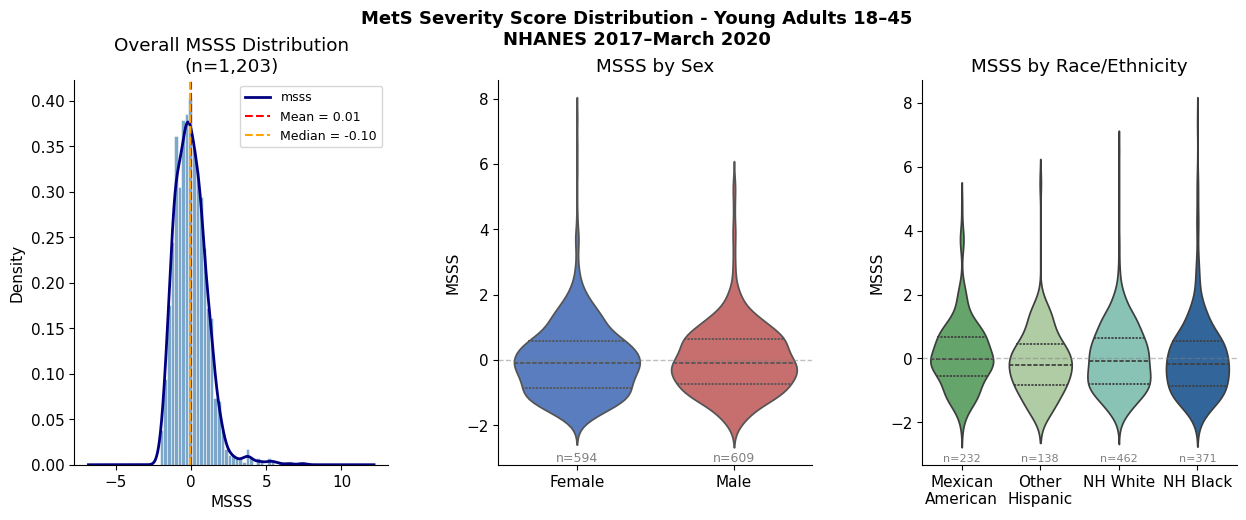

   Overall  : mean=0.010  std=1.104  median=-0.097

   By Sex:
   Male     : n=594  mean=0.018  std=1.076
   Female   : n=609  mean=0.003  std=1.130

   By Race/Ethnicity:
   Mexican American     : n=232  mean=0.118  std=1.068
   Other Hispanic       : n=138  mean=-0.121  std=1.009
   NH White             : n=462  mean=0.001  std=1.033
   NH Black             : n=371  mean=0.004  std=1.234


In [14]:
# Cell 4: MSSS Distribution

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Plot styling
plt.rcParams.update({
    'font.family' : 'sans-serif',
    'font.size' : 11,
    'axes.spines.top' : False,
    'axes.spines.right' : False,
})

# loading modeling cohort for demographic labels
cohort = pd.read_csv(os.path.join(data_proc, 'modeling_cohort.csv'),
                     low_memory=False)

# Merge MSSS with demographics
msss_df = pd.DataFrame({'msss': y.values})
msss_df['sex'] = cohort['RIAGENDR'].values
msss_df['race'] = cohort['RIDRETH3'].values

# Labels
sex_labels  = {1.0: 'Male', 2.0: 'Female'}
race_labels = {
    1.0: 'Mexican\nAmerican',
    2.0: 'Other\nHispanic',
    3.0: 'NH White',
    4.0: 'NH Black',
}

msss_df['sex_label'] = msss_df['sex'].map(sex_labels)
msss_df['race_label'] = msss_df['race'].map(race_labels)
msss_df = msss_df.dropna(subset = ['race_label'])       # Remove Asian/Other

# Figure

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel 1: Overall distribution
ax1 = fig.add_subplot(gs[0])
ax1.hist(y, bins=40, color='steelblue', alpha=0.7,
         edgecolor='white', linewidth=0.5, density=True)
y.plot.kde(ax=ax1, color='navy', linewidth=2)
ax1.axvline(y.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean = {y.mean():.2f}')
ax1.axvline(y.median(), color='orange', linestyle='--',
            linewidth=1.5, label=f'Median = {y.median():.2f}')
ax1.set_xlabel('MSSS')
ax1.set_ylabel('Density')
ax1.set_title('Overall MSSS Distribution\n(n=1,203)')
ax1.legend(fontsize=9)

# Panel 2: By sex
ax2 = fig.add_subplot(gs[1])
sns.violinplot(data=msss_df, x='sex_label', y='msss',
               palette=['#4878CF', '#D65F5F'],
               inner='quartile', ax=ax2)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('')
ax2.set_ylabel('MSSS')
ax2.set_title('MSSS by Sex')

# Add sample sizes
for i, sex in enumerate(['Male', 'Female']):
    n = (msss_df['sex_label'] == sex).sum()
    ax2.text(i, ax2.get_ylim()[0] + 0.1, f'n={n:,}',
             ha='center', fontsize=9, color='gray')

# Panel 3: By race/ethnicity
ax3 = fig.add_subplot(gs[2])
race_order  = ['Mexican\nAmerican', 'Other\nHispanic', 'NH White', 'NH Black']
race_colors = ['#5AAE61', '#ACD39E', '#7FCDBB', '#2166AC']
sns.violinplot(data=msss_df, x='race_label', y='msss',
               order=race_order, palette=race_colors,
               inner='quartile', ax=ax3)
ax3.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('')
ax3.set_ylabel('MSSS')
ax3.set_title('MSSS by Race/Ethnicity')

for i, race in enumerate(race_order):
    n = (msss_df['race_label'] == race).sum()
    ax3.text(i, ax3.get_ylim()[0] + 0.1, f'n={n:,}',
             ha='center', fontsize=8, color='gray')

plt.suptitle('MetS Severity Score Distribution - Young Adults 18–45\nNHANES 2017–March 2020',
             fontsize=13, fontweight='bold', y=1.02)

# Save
save_path = os.path.join(fig_dir, '01_mass_distribution.png')
plt.savefig(save_path, dpi = 160, bbox_inches='tight')
plt.show()

# Summary Statistics
print(f"   Overall  : mean={y.mean():.3f}  std={y.std():.3f}  "
      f"median={y.median():.3f}")
print(f"\n   By Sex:")
for label in ['Male', 'Female']:
    vals = msss_df[msss_df['sex_label'] == label]['msss']
    print(f"   {label:<8} : n={len(vals):,}  "
          f"mean={vals.mean():.3f}  std={vals.std():.3f}")

print(f"\n   By Race/Ethnicity:")
for race in race_order:
    vals = msss_df[msss_df['race_label'] == race]['msss']
    print(f"   {race.replace(chr(10), ' '):<20} : n={len(vals):,}  "
          f"mean={vals.mean():.3f}  std={vals.std():.3f}")

In [17]:
# Drop survey weights and design variables from X_clean
cols_to_drop = [
    'WTDR2DPP', 'WTDR2DPP_DR2TOT',
    'WTDRD1PP', 'WTDRD1PP_DR2TOT',
    'WTINTPRP', 'WTSAFPRP', 'WTSAFPRP_GLU',
    'SDMVPSU',  'SDMVSTRA'
]
cols_to_drop = [c for c in cols_to_drop if c in X_clean.columns]
X_clean = X_clean.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns")
print(f"X_clean shape: {X_clean.shape[0]:,} rows x {X_clean.shape[1]:,} columns")

Dropped 9 columns
X_clean shape: 1,203 rows x 261 columns


In [19]:
# Check if glucose SI units are in X_clean
glucose_cols = [c for c in X_clean.columns if 'GL' in c or 'GLU' in c.upper()]
print("Glucose-related columns in X_clean:")
for col in glucose_cols:
    corr = abs(imputed_1[col].corr(y))
    print(f"   {col:<20} corr with MSSS = {corr:.4f}")

Glucose-related columns in X_clean:
   LBXSGL               corr with MSSS = 0.6777
   LBDSGLSI             corr with MSSS = 0.6783


In [20]:
# Drop glucose leakage columns
glucose_leakage = ['LBXSGL', 'LBDSGLSI']
glucose_leakage = [c for c in glucose_leakage if c in X_clean.columns]

X_clean = X_clean.drop(columns=glucose_leakage)

print(f"Dropped {len(glucose_leakage)} glucose leakage columns: {glucose_leakage}")
print(f"X_clean shape: {X_clean.shape[0]:,} rows x {X_clean.shape[1]:,} columns")

Dropped 2 glucose leakage columns: ['LBXSGL', 'LBDSGLSI']
X_clean shape: 1,203 rows x 259 columns


In [26]:
# Drop SI duplicate columns where LBX conventional unit version exists
si_duplicates = [
    'LBDSALSI',   # albumin SI        keep LBXSAL
    'LBDSBUSI',   # BUN SI            keep LBXSBU
    'LBDSCASI',   # calcium SI        keep LBXSCA
    'LBDSCHSI',   # cholesterol SI    keep LBXSCH
    'LBDSCRSI',   # creatinine SI     keep LBXSCR
    'LBDSGBSI',   # globulin SI       keep LBXSGB
    'LBDSPHSI',   # phosphorus SI     keep LBXSPH
    'LBDSTPSI',   # total protein SI  keep LBXSTP
    'LBDSTRSI',   # bilirubin SI      keep LBXSTR
    'LBDSUASI',   # uric acid SI      keep LBXSUA
    'LBDSTBSI',   # total bilirubin SI keep LBXSTB
]

si_duplicates = [c for c in si_duplicates if c in X_clean.columns]
X_clean = X_clean.drop(columns=si_duplicates)

print(f"Dropped {len(si_duplicates)} SI duplicate columns")
print(f"X_clean shape: {X_clean.shape[0]:,} rows x {X_clean.shape[1]:,} columns")

Dropped 11 SI duplicate columns
X_clean shape: 1,203 rows x 248 columns


In [ ]:
# Cell 5: Domain-Level Correlations with MSSS

# Updated domain map after all drops
domains = {
    'Biochemistry'  : [c for c in X_clean.columns if c.startswith('LBX') or c.startswith('LBD')],
    'Dietary'       : [c for c in X_clean.columns if c.startswith('DR') or c in ['DBD100', 'DBQ095Z']],
    'Demographics'  : [c for c in X_clean.columns if c.startswith('RIA') or c.startswith('DMD') or
                       c.startswith('IND') or c in ['RIDAGEYR', 'RIDEXMON', 'RIDRETH1', 'RIDRETH3',
                       'AIALANGA', 'FIALANG', 'MIALANG', 'SIALANG']],
    'Sleep'         : [c for c in X_clean.columns if c.startswith('SL')],
    'Mental Health' : [c for c in X_clean.columns if c.startswith('DPQ')],
    'Smoking'       : [c for c in X_clean.columns if c.startswith('SMQ') or c.startswith('SMD')],
    'Alcohol'       : [c for c in X_clean.columns if c.startswith('ALQ')],
    'Physical Act.' : [c for c in X_clean.columns if c.startswith('PAD') or c == 'total_MET_minutes'],
    'Body Measures' : [c for c in X_clean.columns if c.startswith('BMX') or c.startswith('BMI')],
    'Blood Pressure': [c for c in X_clean.columns if c.startswith('BPX') or c.startswith('BPA')],
}

# Load imputed dataset 1 for correlation analysis
imputed_1 = pd.read_csv(os.path.join(data_proc, 'x_imputed_1.csv'))

# Drop weight/design columns from imputed dataset too if present
imputed_1 = imputed_1.drop(columns=cols_to_drop, errors='ignore')

# Compute mean absolute correlation per domain with MSSS
print("Domain-level correlations with MSSS:\n")
print(f"   {'Domain':<15} {'Columns':>8} {'Mean |r|':>10} {'Max |r|':>10} {'Top Predictor':<25}")
print('   ' + '-' * 72)

domain_results = {}

for domain, cols in domains.items():
    cols_present = [c for c in cols if c in imputed_1.columns]
    if not cols_present:
        continue

    corrs = imputed_1[cols_present].corrwith(y).abs()
    mean_r = corrs.mean()
    max_r  = corrs.max()
    top    = corrs.idxmax()

    domain_results[domain] = {
        'n_cols' : len(cols_present),
        'mean_r' : mean_r,
        'max_r'  : max_r,
        'top'    : top
    }

    print(f"   {domain:<15} {len(cols_present):>8} {mean_r:>10.4f} {max_r:>10.4f} {top:<25}")

# Bar chart of mean absolute correlation by domain
fig, ax = plt.subplots(figsize=(10, 5))

domain_names = list(domain_results.keys())
mean_rs      = [domain_results[d]['mean_r'] for d in domain_names]
max_rs       = [domain_results[d]['max_r']  for d in domain_names]

x = range(len(domain_names))
bars = ax.bar(x, mean_rs, color='steelblue', alpha=0.8, label='Mean |r|')
ax.bar(x, max_rs, color='navy', alpha=0.3, label='Max |r|', width=0.4)

ax.set_xticks(x)
ax.set_xticklabels(domain_names, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Absolute Correlation with MSSS')
ax.set_title('Domain-Level Correlation with MSSS\n(Dataset 1, n=1,203)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

save_path = os.path.join(fig_dir, '02_domain_correlations.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved: {save_path}")

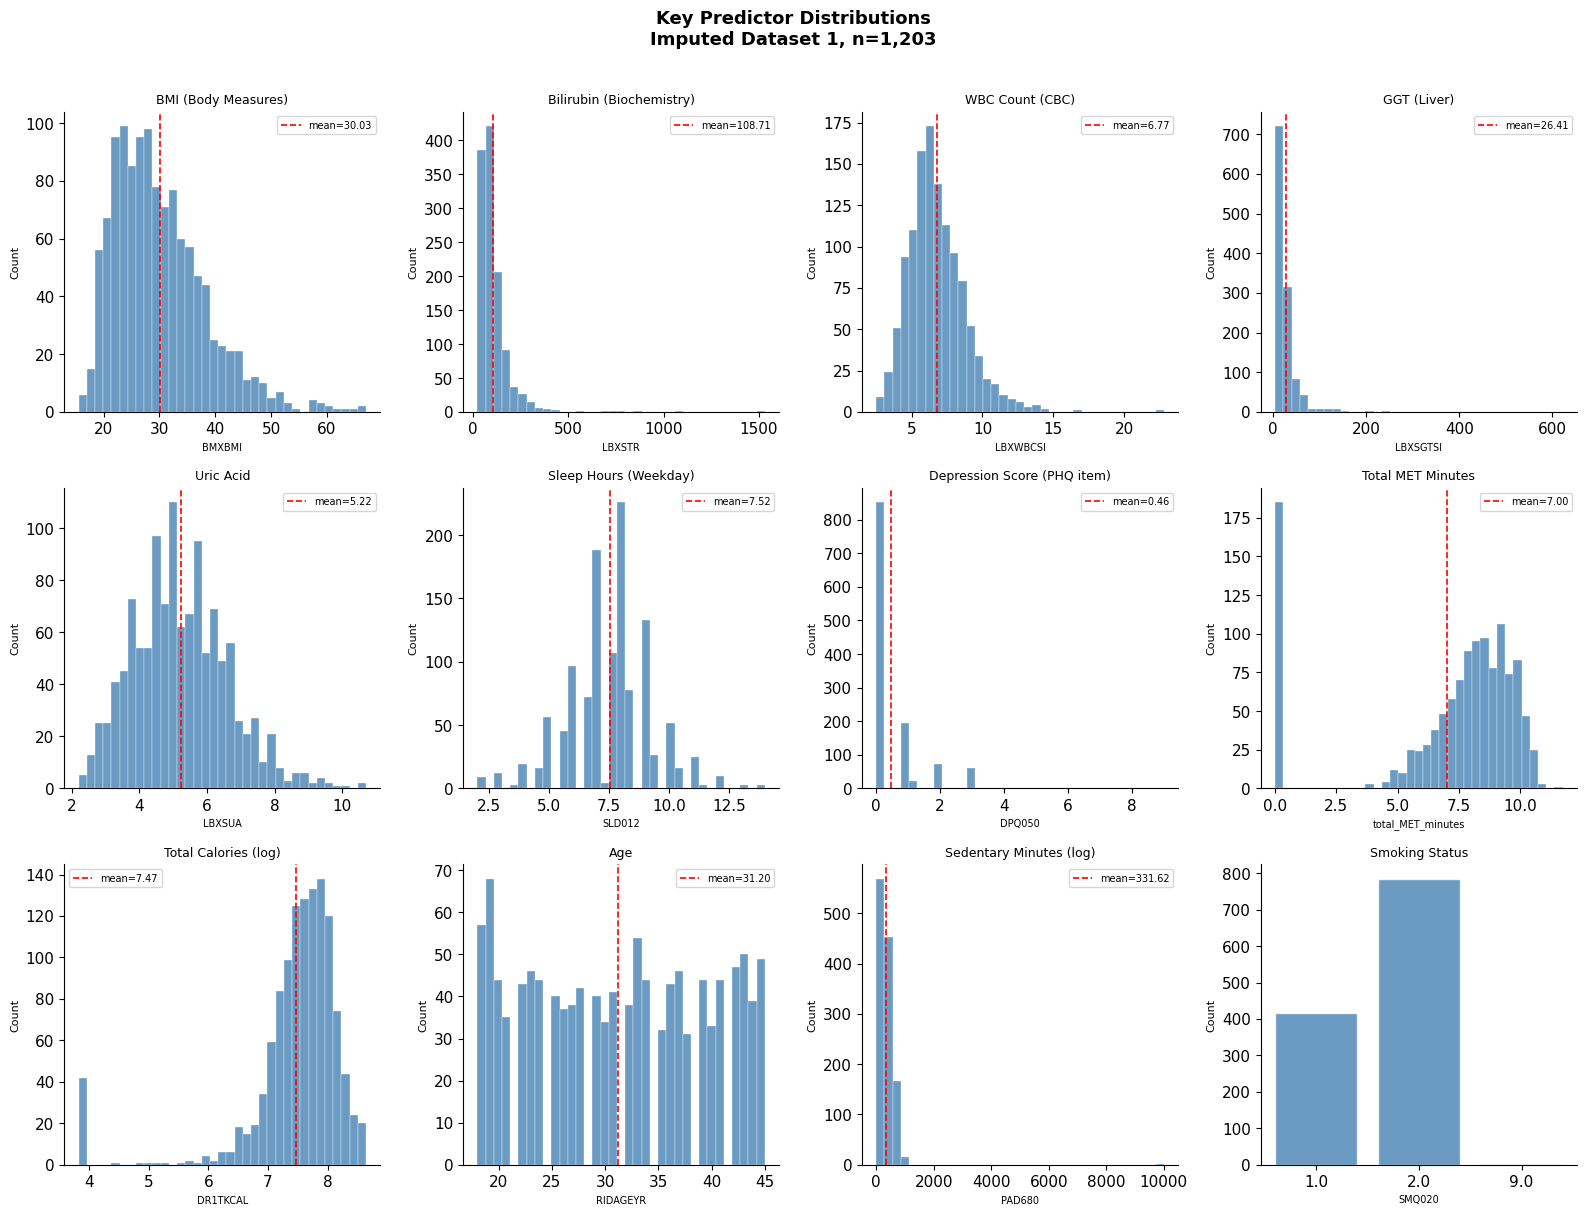

Figure saved: /content/drive/MyDrive/mets-risk-score/outputs/figures/03_predictor_distributions.png


In [28]:
# Cell 6: Key Predictor Distributions

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Key predictors across domains - one representative per domain
key_predictors = {
    'BMI (Body Measures)'        : 'BMXBMI',
    'Bilirubin (Biochemistry)'   : 'LBXSTR',
    'WBC Count (CBC)'            : 'LBXWBCSI',
    'GGT (Liver)'                : 'LBXSGTSI',
    'Uric Acid'                  : 'LBXSUA',
    'Sleep Hours (Weekday)'      : 'SLD012',
    'Depression Score (PHQ item)': 'DPQ050',
    'Total MET Minutes'          : 'total_MET_minutes',
    'Total Calories (log)'       : 'DR1TKCAL',
    'Age'                        : 'RIDAGEYR',
    'Sedentary Minutes (log)'    : 'PAD680',
    'Smoking Status'             : 'SMQ020',
}

for i, (label, col) in enumerate(key_predictors.items()):
    ax = axes[i]

    if col not in imputed_1.columns:
        ax.text(0.5, 0.5, f'{col}\nnot found',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label, fontsize=9)
        continue

    vals = imputed_1[col].dropna()

    # Use histogram for low-cardinality columns, KDE for continuous
    if vals.nunique() <= 5:
        counts = vals.value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values,
               color='steelblue', alpha=0.8, edgecolor='white')
    else:
        ax.hist(vals, bins=35, color='steelblue',
                alpha=0.8, edgecolor='white', linewidth=0.3)
        ax.axvline(vals.mean(), color='red',
                   linestyle='--', linewidth=1.2,
                   label=f'mean={vals.mean():.2f}')
        ax.legend(fontsize=7)

    ax.set_title(label, fontsize=9)
    ax.set_xlabel(col, fontsize=7)
    ax.set_ylabel('Count', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Key Predictor Distributions\nImputed Dataset 1, n=1,203',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

save_path = os.path.join(fig_dir, '03_predictor_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: {save_path}")